#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

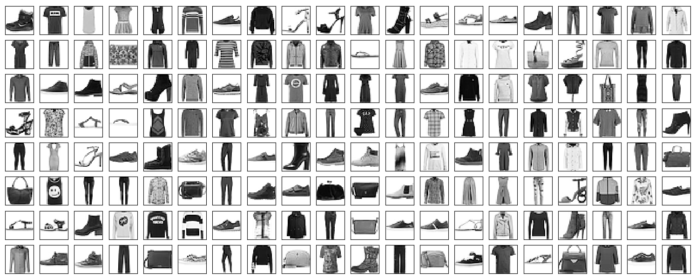


In [1]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

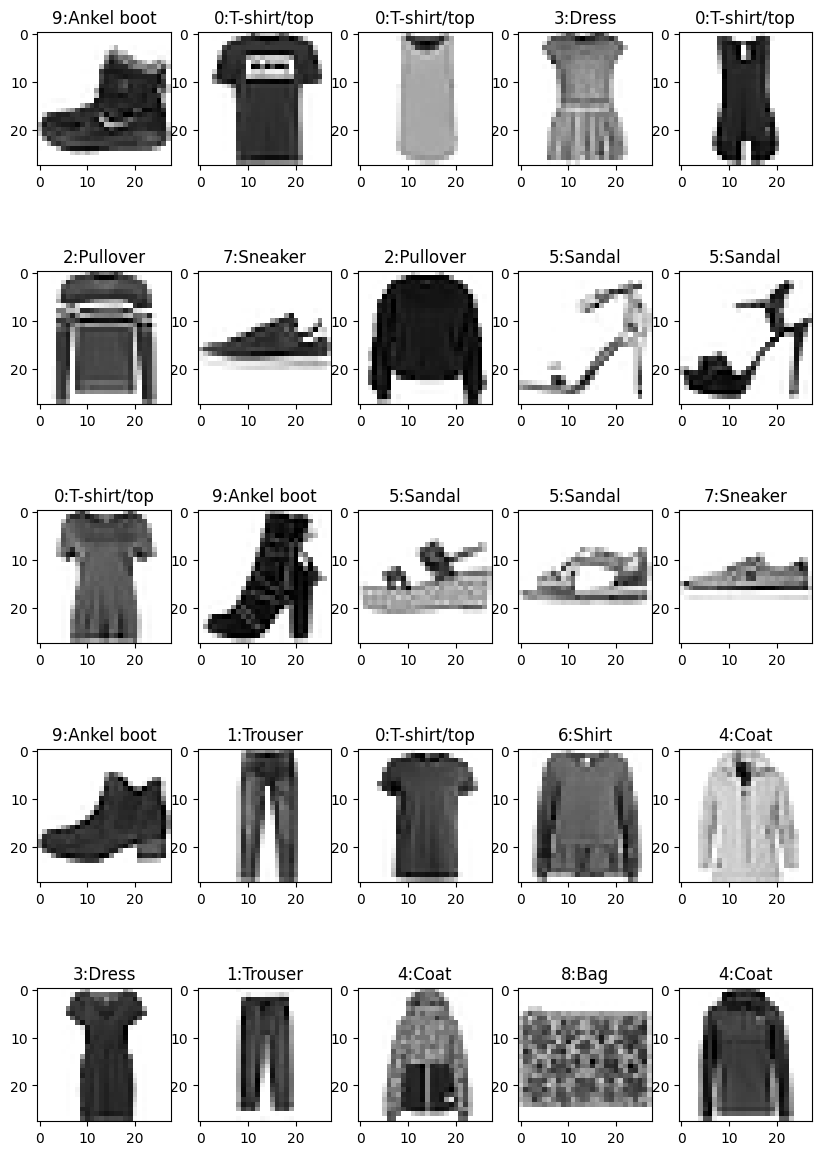

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

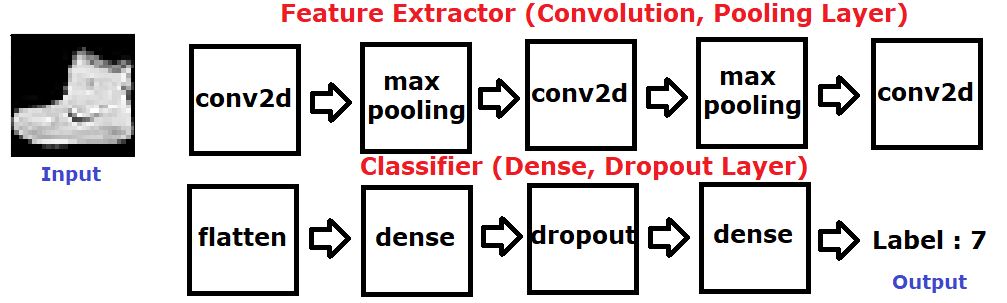

## Feature Extractor

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [10]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8504 - loss: 0.4098 - val_accuracy: 0.8903 - val_loss: 0.3077
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9050 - loss: 0.2611 - val_accuracy: 0.9100 - val_loss: 0.2487
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2155 - val_accuracy: 0.9123 - val_loss: 0.2434
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9335 - loss: 0.1811 - val_accuracy: 0.9179 - val_loss: 0.2335
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9424 - loss: 0.1541 - val_accuracy: 0.9237 - val_loss: 0.2125
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9521 - loss: 0.1244 - val_accuracy: 0.9190 - val_loss: 0.2424
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9602 - loss: 0.1032 - val_accuracy: 0.9158 - val_loss: 0.2468
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9689 - loss: 0.0851 -

In [13]:
def plot_history(history):
  plt.figure(figsize=(15, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history['accuracy'])
  plt.plot(history['val_accuracy'])
  plt.legend(['train', 'validation'])
  plt.title('Accuracy')
  plt.subplot(1, 2, 2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train', 'validation'])
  plt.title('Loss')
  plt.show()

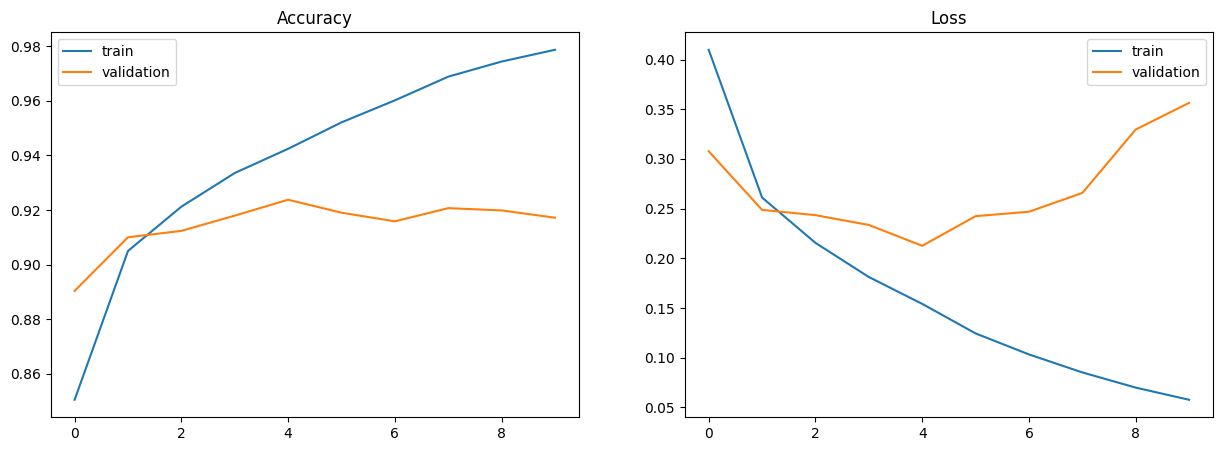

In [14]:
plot_history(history.history)

In [15]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9122 - loss: 0.3988


[0.39883744716644287, 0.9121999740600586]

#Drop out
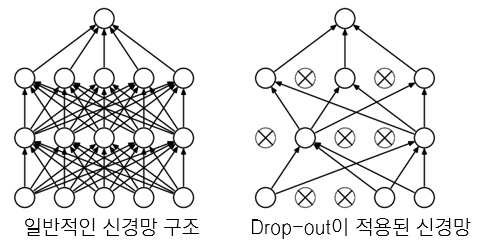

In [16]:
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model1.add(layers.MaxPooling2D((2,2), strides=2))
model1.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model1.add(layers.MaxPooling2D((2,2), strides=2))
model1.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model1.add(layers.Flatten())
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(10, activation='softmax'))
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
history = model1.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8309 - loss: 0.4670 - val_accuracy: 0.8890 - val_loss: 0.3025
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8917 - loss: 0.2993 - val_accuracy: 0.9015 - val_loss: 0.2608
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9087 - loss: 0.2495 - val_accuracy: 0.9095 - val_loss: 0.2489
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9201 - loss: 0.2178 - val_accuracy: 0.9121 - val_loss: 0.2307
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9300 - loss: 0.1907 - val_accuracy: 0.9182 - val_loss: 0.2271
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9383 - loss: 0.1668 - val_accuracy: 0.9188 - val_loss: 0.2373
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9450 - loss: 0.1489 - val_accuracy: 0.9221 - val_loss: 0.2345
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9506 - loss: 0.1297 

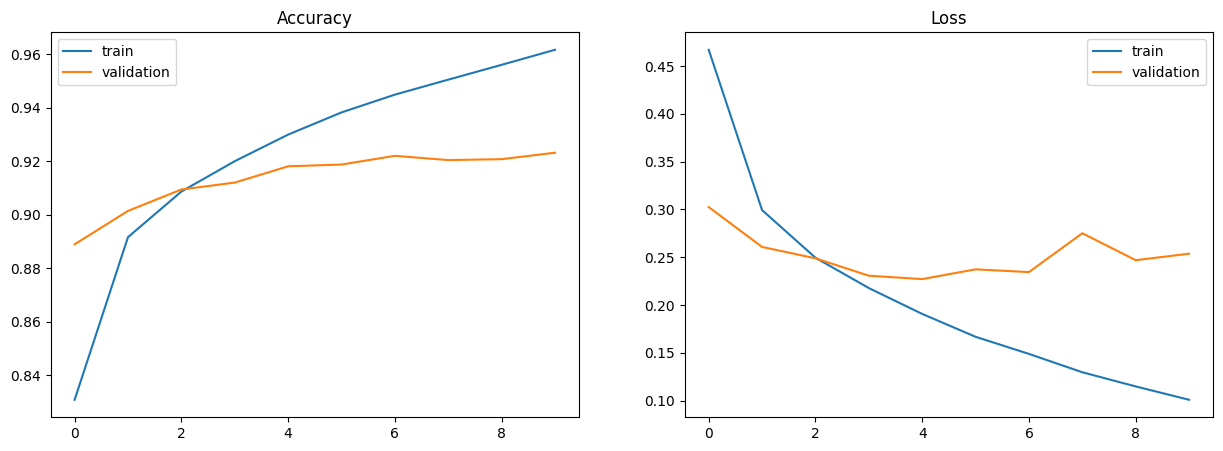

In [19]:
plot_history(history.history)

In [20]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9168 - loss: 0.2764


[0.2763823866844177, 0.9168000221252441]

## BatchNormalization
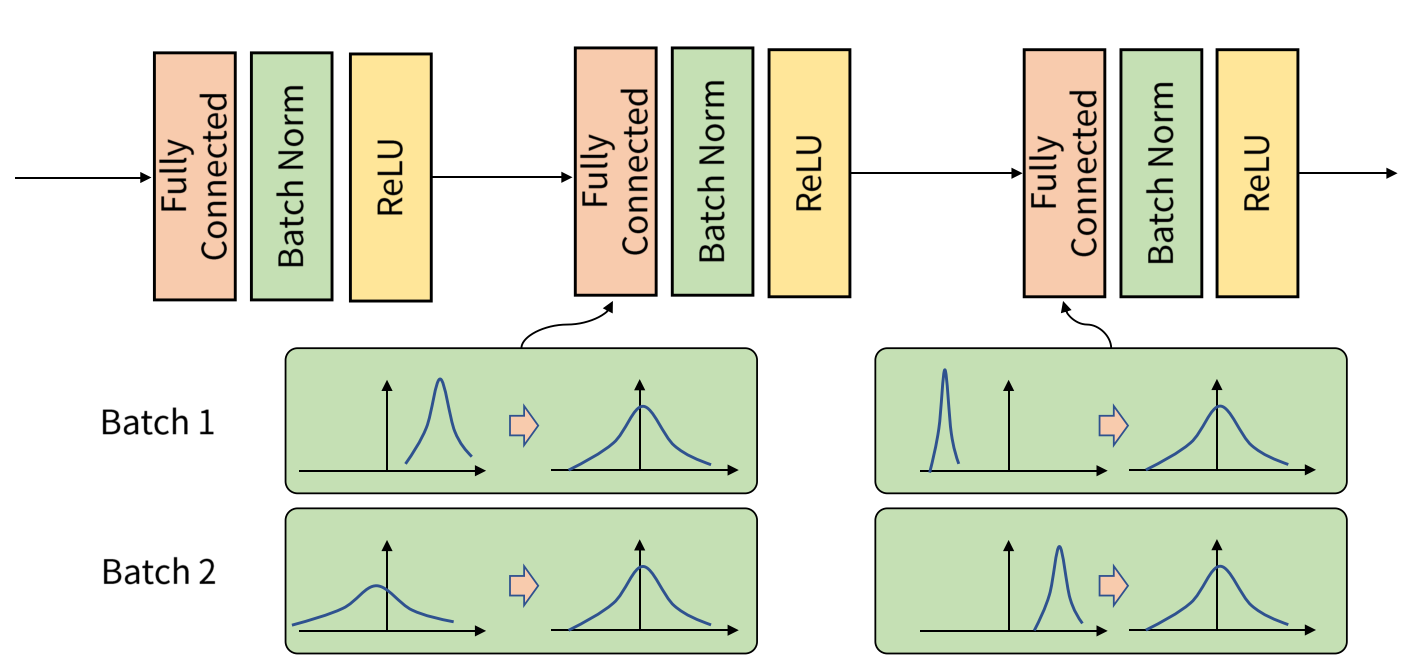

In [21]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [22]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8525 - loss: 0.4140 - val_accuracy: 0.8871 - val_loss: 0.3065
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8972 - loss: 0.2845 - val_accuracy: 0.8848 - val_loss: 0.3089
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9125 - loss: 0.2393 - val_accuracy: 0.8991 - val_loss: 0.2805
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9207 - loss: 0.2135 - val_accuracy: 0.8331 - val_loss: 0.5079
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9285 - loss: 0.1876 - val_accuracy: 0.9144 - val_loss: 0.2498
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9376 - loss: 0.1681 - val_accuracy: 0.8983 - val_loss: 0.2914
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9424 - loss: 0.1541 - val_accuracy: 0.9152 - val_loss: 0.2662
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9495 - loss: 0.1339 

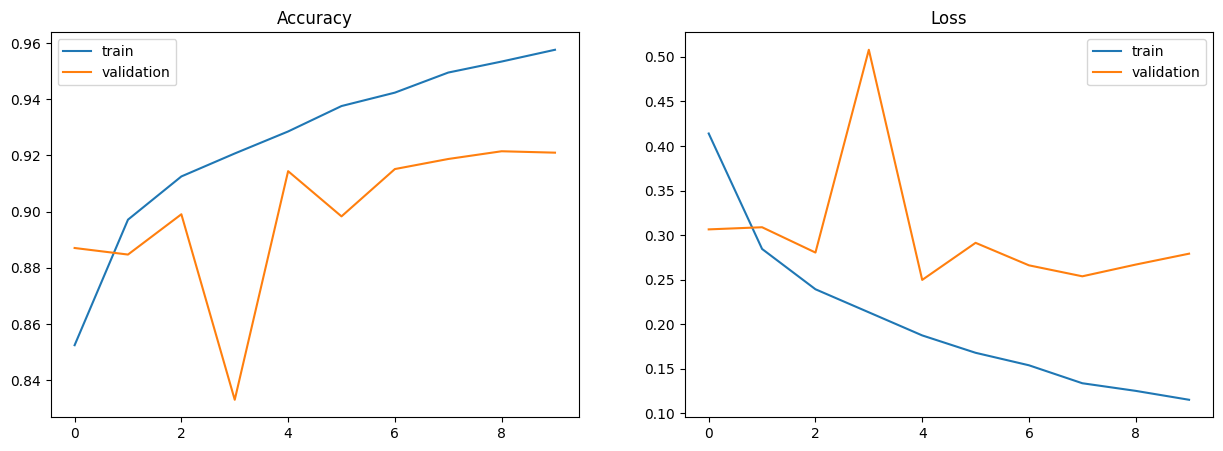

In [24]:
plot_history(history.history)

In [25]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9200 - loss: 0.2980


[0.29800310730934143, 0.9200000166893005]

#Callback

In [26]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model3.add(layers.Dropout(0.3))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [28]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras')
history = model3.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8311 - loss: 0.4674 - val_accuracy: 0.8733 - val_loss: 0.3484
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8906 - loss: 0.3009 - val_accuracy: 0.9031 - val_loss: 0.2762
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9074 - loss: 0.2563 - val_accuracy: 0.9094 - val_loss: 0.2477
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9170 - loss: 0.2244 - val_accuracy: 0.9118 - val_loss: 0.2371
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9272 - loss: 0.1996 - val_accuracy: 0.9188 - val_loss: 0.2266
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9320 - loss: 0.1804 - val_accuracy: 0.9173 - val_loss: 0.2373
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9396 - loss: 0.1600 - val_accuracy: 0.9151 - val_loss: 0.2432
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9460 - loss: 0.1440 

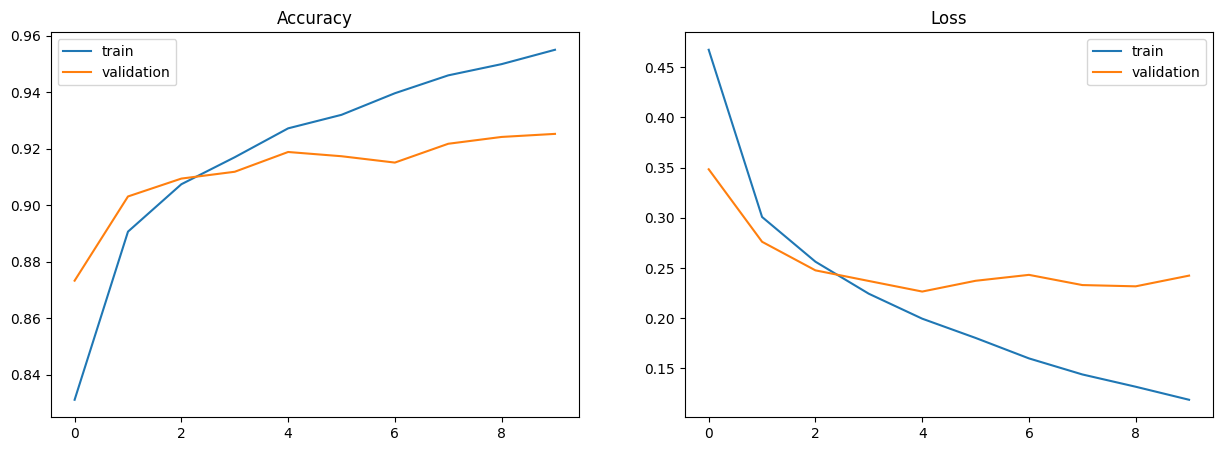

In [29]:
plot_history(history.history)

In [30]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9178 - loss: 0.2750


[0.2750342786312103, 0.9178000092506409]

In [31]:
model4 = models.Sequential()
model4.add(layers.Input(shape=(28,28,1)))
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [33]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras')
earlystopping_cb = keras.callbacks.EarlyStopping(patience=3,
                              restore_best_weights=True)
history = model4.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb, earlystopping_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8351 - loss: 0.4587 - val_accuracy: 0.8868 - val_loss: 0.3252
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8920 - loss: 0.3028 - val_accuracy: 0.8979 - val_loss: 0.2723
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9061 - loss: 0.2562 - val_accuracy: 0.9118 - val_loss: 0.2396
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9168 - loss: 0.2258 - val_accuracy: 0.9114 - val_loss: 0.2486
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9258 - loss: 0.2009 - val_accuracy: 0.9181 - val_loss: 0.2275
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9341 - loss: 0.1777 - val_accuracy: 0.9162 - val_loss: 0.2343
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9395 - loss: 0.1621 - val_accuracy: 0.9187 - val_loss: 0.2276
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9467 - loss: 0.1423 

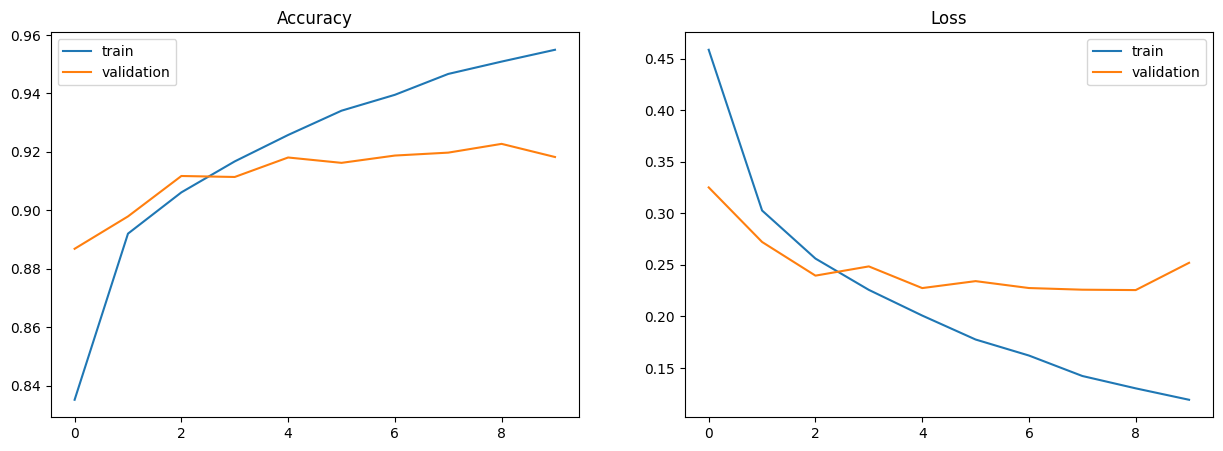

In [34]:
plot_history(history.history)

In [35]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.095 0.    0.003 0.    0.001 0.    0.901 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.313 0.    0.687 0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.005 0.    0.994 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.005 0.    0.986 0.    0.009 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.216 0.    0.784 0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.151 0.    0.839 0.    0.011 0.    0.    0.   ]
 [0.    1.    0.

In [36]:
np.argmax(pred,axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 6, 8, 0, 2, 5,
       7, 5, 1])

In [37]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


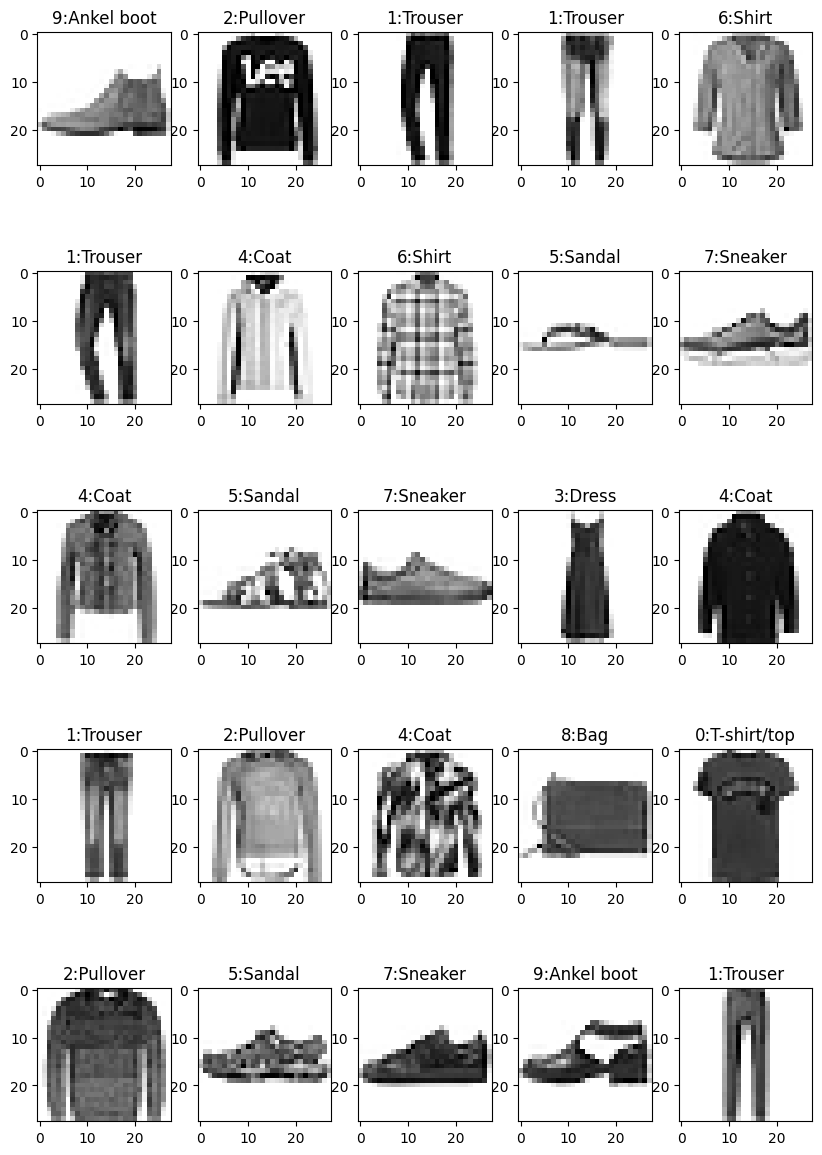

In [38]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

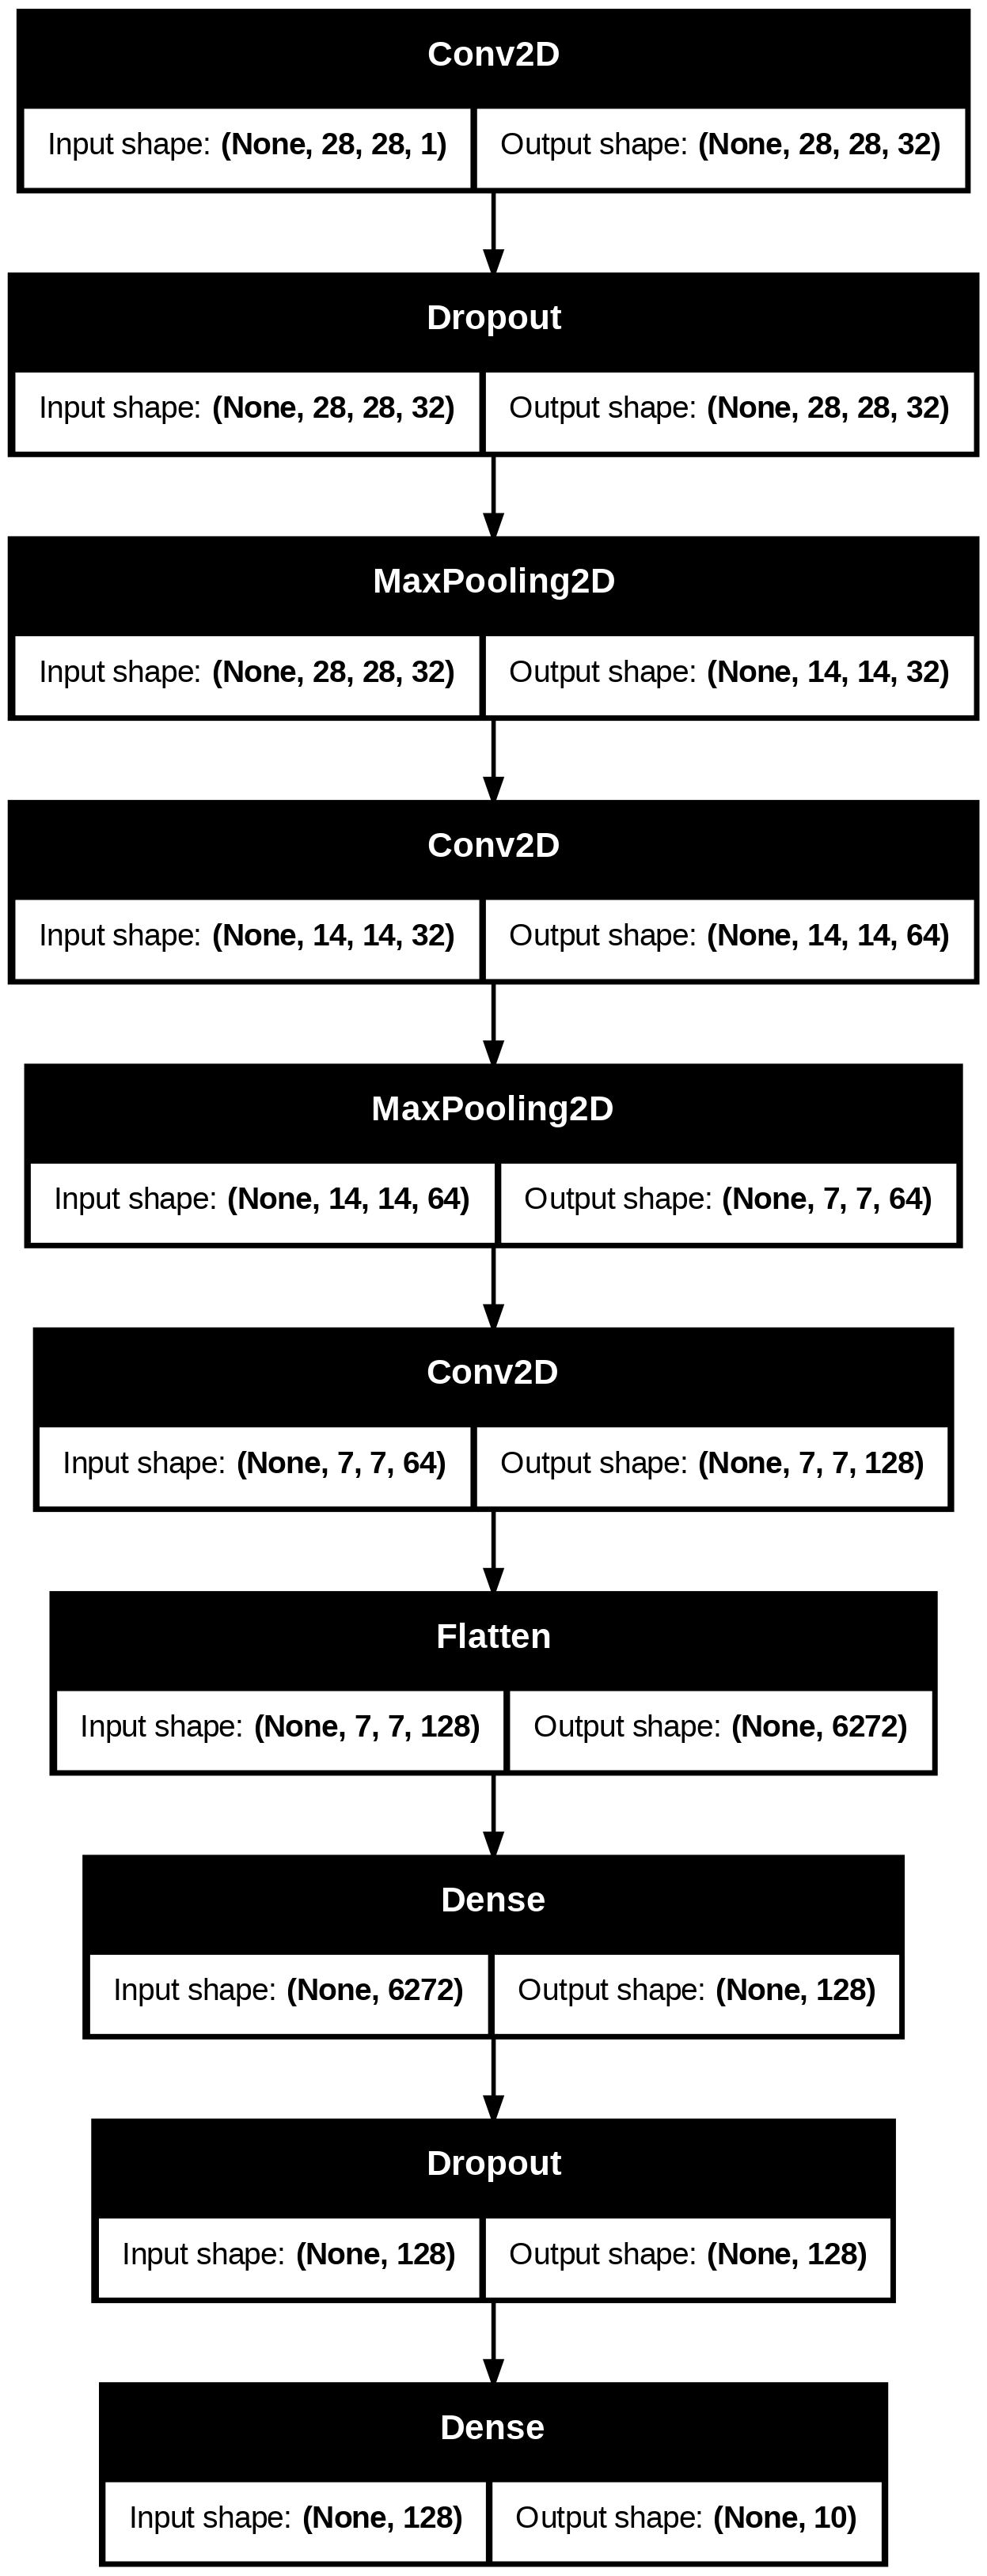

In [39]:
utils.plot_model(model4, show_shapes=True, to_file='fmist.png')

### 학습된 Conv층 가져오기

In [40]:
model4.layers

[<Conv2D name=conv2d_12, built=True>,
 <Dropout name=dropout_4, built=True>,
 <MaxPooling2D name=max_pooling2d_8, built=True>,
 <Conv2D name=conv2d_13, built=True>,
 <MaxPooling2D name=max_pooling2d_9, built=True>,
 <Conv2D name=conv2d_14, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_5, built=True>,
 <Dense name=dense_9, built=True>]

In [41]:
conv=model4.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [42]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

(3, 3, 1, 32)
[[[[ 0.16424258 -0.08295479  0.23001568  0.18774056 -0.10629804
    -0.10620375 -0.03608644  0.2273581   0.0204656   0.01188662
    -0.31685105 -0.13239472  0.08587742 -0.03151112  0.05727024
     0.06257645 -0.01019487 -0.08315089  0.07391916  0.01834491
     0.1420381  -0.01661615 -0.24436846 -0.7846916  -0.06168291
    -0.01064624 -0.30102664  0.06583899 -0.09009073 -0.16744989
     0.00725601 -0.01647467]]

  [[-0.02158817 -0.11002614 -0.15665294 -0.08586745 -0.10726181
    -0.21131253 -0.05146856  0.01275356 -0.02321575  0.04909546
    -0.09930403  0.30590507  0.09503062  0.2016215   0.03982787
     0.17162523  0.10351933  0.15489992  0.18338594 -0.28151754
     0.03476244  0.10328199  0.13266025 -0.5024968   0.18123576
     0.12997714 -0.6211052   0.14837189  0.09151968 -0.03429435
    -0.02464291  0.0028221 ]]

  [[-0.17539172  0.37222844 -0.05274279 -0.16575766  0.19824669
     0.27435184 -0.2487923  -0.24848463  0.05177227 -0.02106825
     0.17250875 -0.14180954 

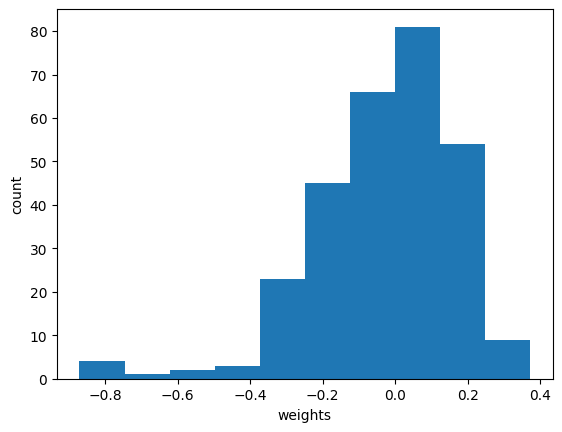

In [43]:
plt.hist(weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [44]:
weights[:, :, 0, 0]

array([[ 0.16424258, -0.02158817, -0.17539172],
       [-0.06818192, -0.11812466, -0.18446068],
       [ 0.10630237,  0.05343488,  0.07168034]], dtype=float32)

In [45]:
weights[:, :, 0, 1]

array([[-0.08295479, -0.11002614,  0.37222844],
       [-0.62719464, -0.80048746, -0.04735948],
       [-0.3047348 , -0.8703197 , -0.2402754 ]], dtype=float32)

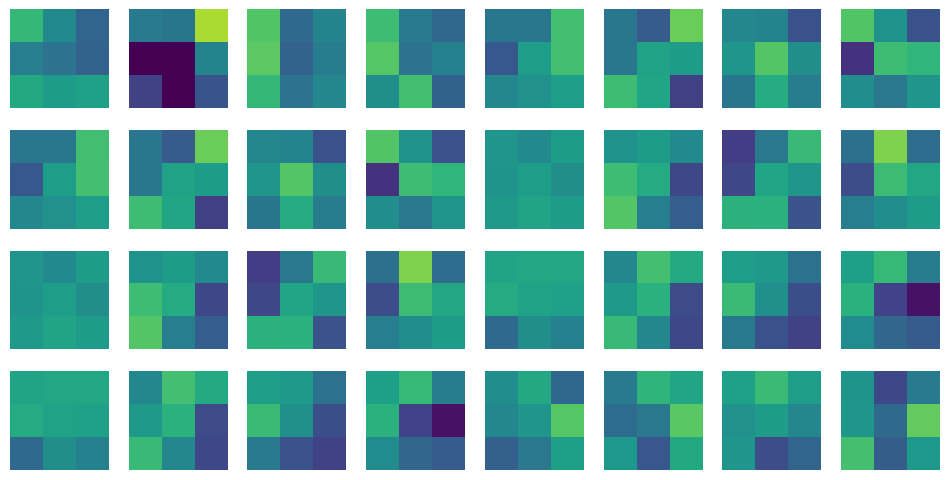

In [46]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [47]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3,3), activation='relu',
                             padding='same', input_shape=(28,28,1)))
init_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
new_conv=init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [49]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

(3, 3, 1, 32)
[[[[ 0.05483402 -0.03737082 -0.04210563  0.09892312 -0.03048502
    -0.11634822  0.08925126 -0.04510392  0.03182885 -0.07240319
    -0.0762537  -0.05428763 -0.03682846 -0.01875088  0.12849073
    -0.06429961  0.05739506 -0.06654986  0.07964024 -0.02257223
    -0.02529317 -0.11741849 -0.08442767  0.00129463  0.12042548
     0.09757064 -0.01012492 -0.06804901  0.12345405 -0.06558326
     0.12041052  0.05562912]]

  [[ 0.03998408 -0.00948039  0.04557237  0.13004966 -0.11530873
    -0.12411527  0.05185339 -0.01697065 -0.127304    0.0119154
    -0.02024474  0.08284429  0.14105882 -0.13056462 -0.11326102
    -0.13815223  0.10505113  0.06592654 -0.1170212  -0.07703514
    -0.07928066 -0.10104152  0.05823597  0.05774248 -0.01143529
    -0.09522177  0.05120625  0.06385006 -0.01267129  0.00307782
    -0.02012535  0.06727481]]

  [[ 0.02634606  0.06305377  0.07685463 -0.04443498  0.06307752
     0.02198343  0.07566482  0.10911168  0.0061491  -0.1396609
     0.09618458  0.00498313 -0

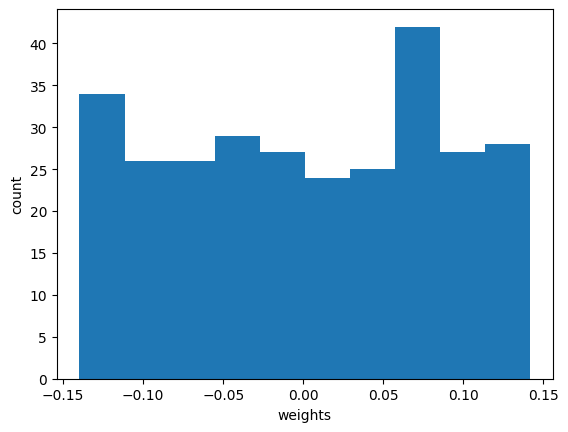

In [50]:
plt.hist(new_weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

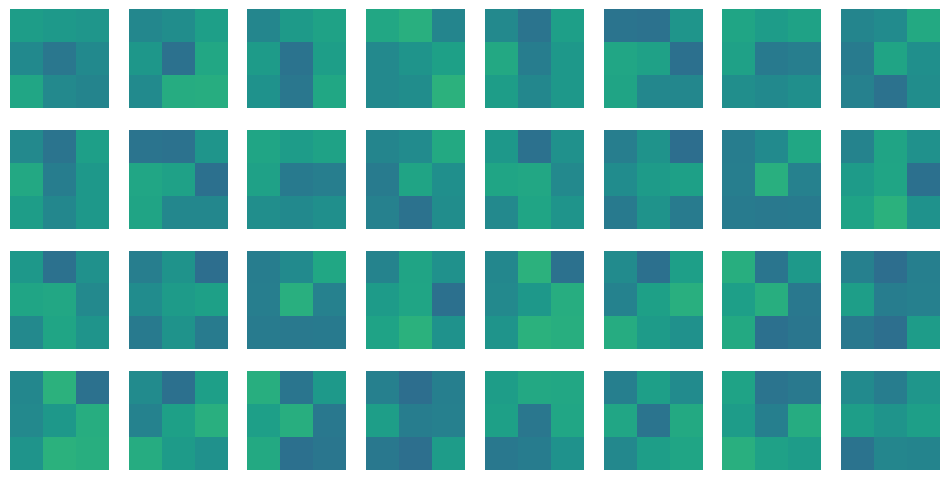

In [51]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 필터를 거친 이미지 확인하기

In [52]:
conv1 = keras.Model(model4.inputs[0], model4.layers[0].output)
conv1.summary()

Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

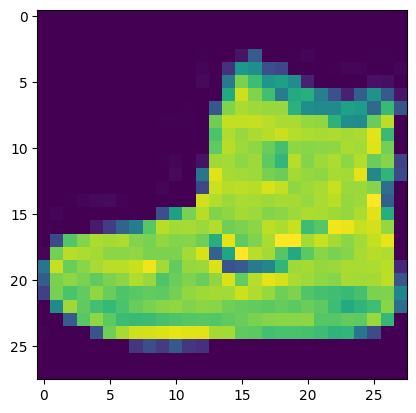

In [53]:
plt.imshow(x_train2d[0])
plt.show()

In [54]:
feature_map1 = conv1.predict(x_train[0:1])
print(feature_map1.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
(1, 28, 28, 32)


In [55]:
feature_map1[0, :, :, 0]

array([[0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335],
       [0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335],
       [0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00179335, 0.00179335, 0.00179335, 0.00179335,
        0.00179335, 0.00207445, 0.0020029 , 0.00221022, 0.00544764,
        0.02503774, 0.0225

In [56]:
feature_map1[0, :, :, 1]

array([[0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169],
       [0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169],
       [0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12732169, 0.12732169, 0.12732169, 0.12732169,
        0.12732169, 0.12637943, 0.12390867, 0.12612665, 0.11507235,
        0.01416773, 0.    

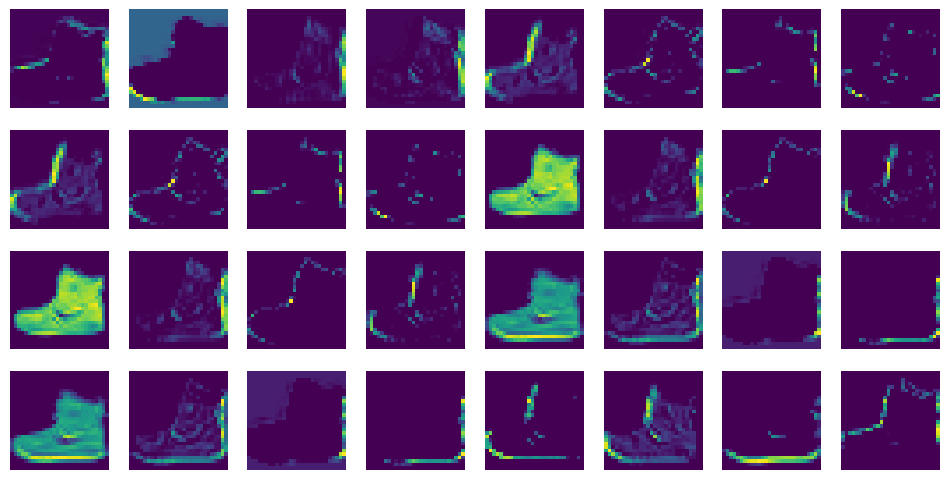

In [57]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [58]:
model4.layers

[<Conv2D name=conv2d_12, built=True>,
 <Dropout name=dropout_4, built=True>,
 <MaxPooling2D name=max_pooling2d_8, built=True>,
 <Conv2D name=conv2d_13, built=True>,
 <MaxPooling2D name=max_pooling2d_9, built=True>,
 <Conv2D name=conv2d_14, built=True>,
 <Flatten name=flatten_4, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_5, built=True>,
 <Dense name=dense_9, built=True>]

In [59]:
conv2 = keras.Model(model4.inputs[0], model4.layers[2].output)
conv2.summary()

Model: "functional_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
(1, 14, 14, 32)


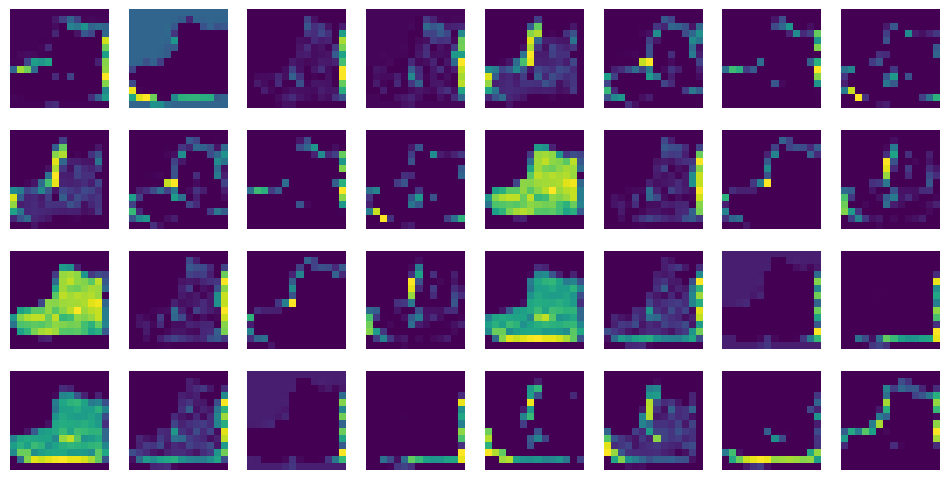

In [61]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [62]:
conv3 = keras.Model(model4.inputs[0], model4.layers[3].output)
conv3.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
(1, 14, 14, 64)


In [64]:
feature_map3[0,:,:,0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00784318, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.47169906, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.7199134 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0. 

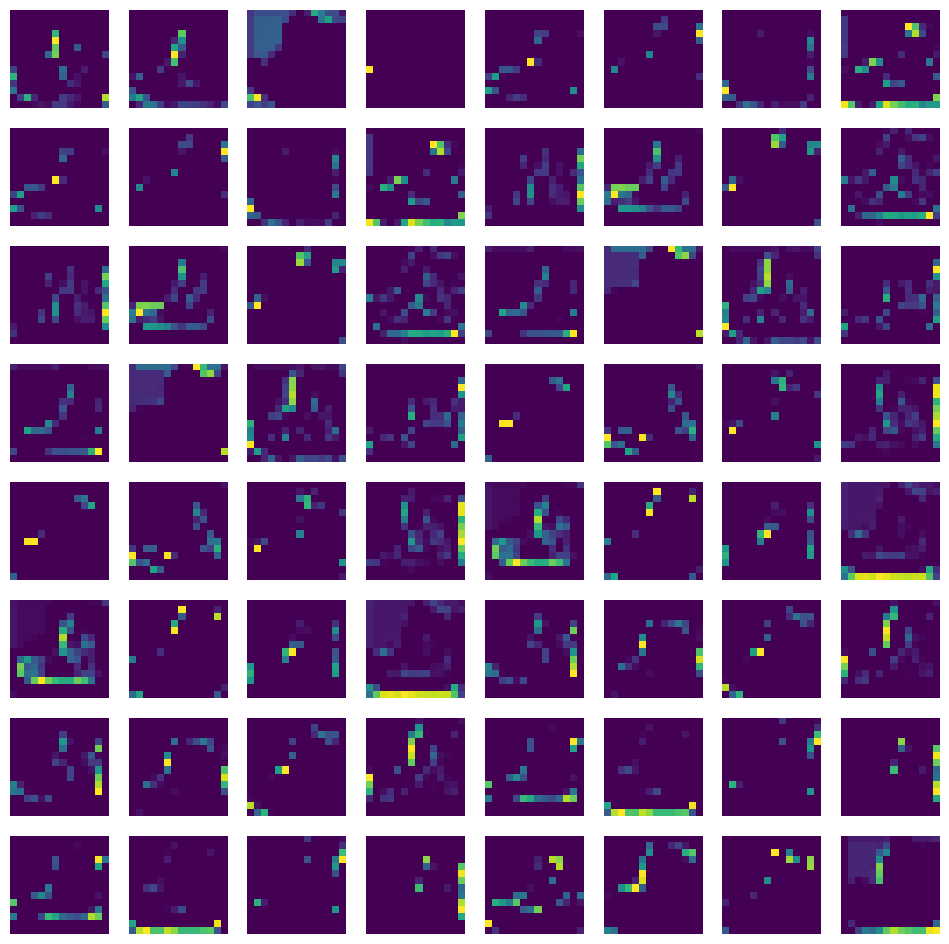

In [65]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()